# Task 1C: Feature Engineering

Transform the mental health smartphone time series dataset into an instance-based dataset suitable for supervised learning.

**Goal:** Predict next-day average mood from historical features using a sliding window approach.

**Steps:**
1. Load cleaned data (with raw fallback)
2. Aggregate raw observations into daily summaries per patient
3. Apply sliding window feature engineering (mean, std, min, max, trend, lags)
4. Build final instance-based dataset: each row = (patient, date, features, target)
5. Analyze feature quality and correlations

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

print("Libraries loaded successfully.")

Libraries loaded successfully.


## Section 1: Load Cleaned Data

We try to load the cleaned dataset from Task 1B. If that file is not available, we fall back to loading and cleaning the raw data directly.

In [2]:
import os

cleaned_path = '../data/dataset_mood_smartphone_cleaned.csv'
raw_path = '../data/dataset_mood_smartphone.csv'

if os.path.exists(cleaned_path):
    df_wide = pd.read_csv(cleaned_path)
    df_wide['date'] = pd.to_datetime(df_wide['date']).dt.date
    data_source = "cleaned (wide format)"
    print(f"Loaded cleaned dataset from {cleaned_path}")
else:
    print(f"Cleaned dataset not found at {cleaned_path}. Loading raw data as fallback...")
    df_raw = pd.read_csv(raw_path)
    if df_raw.columns[0] == '' or df_raw.columns[0].startswith('Unnamed'):
        df_raw = df_raw.drop(columns=df_raw.columns[0])
    df_raw['time'] = pd.to_datetime(df_raw['time'])
    df_raw['date'] = df_raw['time'].dt.date
    df_raw['value'] = pd.to_numeric(df_raw['value'], errors='coerce')
    # We will handle aggregation below
    df_wide = None
    data_source = "raw (long format)"
    print(f"Loaded raw dataset from {raw_path}")

if df_wide is not None:
    feature_vars_all = [c for c in df_wide.columns if c not in ['id', 'date']]
    print(f"\nData source: {data_source}")
    print(f"Dataset shape: {df_wide.shape}")
    print(f"Number of patients: {df_wide['id'].nunique()}")
    print(f"Variables: {sorted(feature_vars_all)}")
    print(f"Date range: {min(df_wide['date'])} to {max(df_wide['date'])}")
    df_wide.head()

Loaded cleaned dataset from ../data/dataset_mood_smartphone_cleaned.csv

Data source: cleaned (wide format)
Dataset shape: (3051, 21)
Number of patients: 27
Variables: ['activity', 'appCat.builtin', 'appCat.communication', 'appCat.entertainment', 'appCat.finance', 'appCat.game', 'appCat.office', 'appCat.other', 'appCat.social', 'appCat.travel', 'appCat.unknown', 'appCat.utilities', 'appCat.weather', 'call', 'circumplex.arousal', 'circumplex.valence', 'mood', 'screen', 'sms']
Date range: 2014-02-17 to 2014-06-09


## Section 2: Daily Aggregation

Convert the long-format time series (multiple observations per day) into wide-format daily summaries per patient. Each variable is aggregated differently based on its nature:

- **mood**: daily mean (self-reported scale 1-10)
- **circumplex.arousal / circumplex.valence**: daily mean
- **activity**: daily mean
- **screen**: daily sum (total screen time)
- **call**: daily count (number of calls)
- **sms**: daily count (number of messages)
- **appCat.\***: daily sum (total usage per category)

In [3]:
# The cleaned data is already in wide format (one row per patient per day).
# We identify variable types for documentation and NaN-filling purposes.
mean_vars = ['mood', 'circumplex.arousal', 'circumplex.valence', 'activity']
sum_vars = ['screen'] + [c for c in df_wide.columns if c.startswith('appCat.')]
count_vars = ['call', 'sms']

print("Variables aggregated by MEAN (in raw data):", mean_vars)
print("Variables aggregated by SUM (in raw data):", sum_vars)
print("Variables aggregated by COUNT (in raw data):", count_vars)

Variables aggregated by MEAN (in raw data): ['mood', 'circumplex.arousal', 'circumplex.valence', 'activity']
Variables aggregated by SUM (in raw data): ['screen', 'appCat.builtin', 'appCat.communication', 'appCat.entertainment', 'appCat.finance', 'appCat.game', 'appCat.office', 'appCat.other', 'appCat.social', 'appCat.travel', 'appCat.unknown', 'appCat.utilities', 'appCat.weather']
Variables aggregated by COUNT (in raw data): ['call', 'sms']


In [4]:
# The cleaned dataset is already aggregated into daily wide format.
# We use it directly as our daily_df.

# def aggregate_daily(...):  # Not needed - data is already aggregated
#     ...

daily_df = df_wide.copy()

print(f"Daily data shape: {daily_df.shape}")
print(f"Patients: {daily_df['id'].nunique()}, Days per patient (approx): {daily_df.groupby('id')['date'].count().mean():.0f}")
print(f"\nColumns: {list(daily_df.columns)}")
daily_df.head(10)

Daily data shape: (3051, 21)
Patients: 27, Days per patient (approx): 113

Columns: ['id', 'date', 'call', 'sms', 'screen', 'appCat.builtin', 'appCat.communication', 'appCat.entertainment', 'appCat.finance', 'appCat.game', 'appCat.office', 'appCat.other', 'appCat.social', 'appCat.travel', 'appCat.unknown', 'appCat.utilities', 'appCat.weather', 'mood', 'circumplex.arousal', 'circumplex.valence', 'activity']


,id,date,call,sms,screen,appCat.builtin,appCat.communication,appCat.entertainment,appCat.finance,appCat.game,...,appCat.other,appCat.social,appCat.travel,appCat.unknown,appCat.utilities,appCat.weather,mood,circumplex.arousal,circumplex.valence,activity
0,AS14.01,2014-02-17,2.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,AS14.01,2014-02-18,1.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,AS14.01,2014-02-19,7.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,AS14.01,2014-02-20,2.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,AS14.01,2014-02-21,0.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,AS14.01,2014-02-22,2.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,AS14.01,2014-02-23,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,AS14.01,2014-02-24,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,AS14.01,2014-02-25,3.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,AS14.01,2014-02-26,1.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,6.25,-0.25,0.75,NaN


In [5]:
# Check missing values in the daily data
missing = daily_df.isnull().sum()
missing_pct = (daily_df.isnull().sum() / len(daily_df) * 100).round(1)
missing_info = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
print("Missing values in daily data:")
print(missing_info[missing_info['missing_count'] > 0])

# Fill missing daily values with 0 for count/sum variables (no observation = no activity)
fill_zero_cols = [c for c in sum_vars + count_vars if c in daily_df.columns]
daily_df[fill_zero_cols] = daily_df[fill_zero_cols].fillna(0)

print(f"\nAfter filling count/sum NaNs with 0: {daily_df.isnull().sum().sum()} remaining NaNs")
print("Remaining NaN columns:", list(daily_df.columns[daily_df.isnull().any()]))

Missing values in daily data:
                      missing_count  missing_pct
screen                         1822         59.7
appCat.builtin                 1829         59.9
appCat.communication           1825         59.8
appCat.entertainment           2027         66.4
appCat.finance                 2685         88.0
appCat.game                    2781         91.2
appCat.office                  2576         84.4
appCat.other                   1850         60.6
appCat.social                  1914         62.7
appCat.travel                  2322         76.1
appCat.unknown                 2589         84.9
appCat.utilities               2358         77.3
appCat.weather                 2821         92.5
mood                           1751         57.4
circumplex.arousal             1751         57.4
circumplex.valence             1751         57.4
activity                       1854         60.8

After filling count/sum NaNs with 0: 7107 remaining NaNs
Remaining NaN columns: ['mood'

### Results: Daily Aggregation and Missing Data

The cleaned dataset contains **3,051 daily records** across **27 patients**, with approximately 113 days per patient spanning February to June 2014. The data includes 19 feature variables covering mood, arousal, valence, activity, screen usage, app categories, calls, and SMS.

Missing data is substantial, particularly for app usage categories. The most affected variables are `appCat.weather` (92.5% missing), `appCat.game` (91.2%), and `appCat.finance` (88.0%). These high rates reflect that many patients simply did not use certain app categories on most days. For count and sum variables (calls, SMS, screen time, app usage), missing values were filled with zero, since the absence of an observation logically indicates no activity. This is a reasonable imputation choice for behavioral counts.

After zero-filling, **7,107 NaN values remain** across four mean-aggregated variables: `mood`, `circumplex.arousal`, `circumplex.valence`, and `activity` (all at roughly 57-61% missing). These variables cannot be zero-filled because their missing values represent genuinely unobserved self-reports, not zero activity. They will be handled during the sliding window phase, where aggregation over the 7-day window can tolerate partial missingness.

## Section 3: Sliding Window Feature Engineering

For each patient, we slide a window of `W` days over their daily time series. From each window we extract:

- **Aggregation features**: mean, std, min, max of each variable over the window
- **Trend features**: linear slope of each variable over the window (captures direction of change)
- **Lag features**: mood values from the previous 1, 2, and 3 days
- **Temporal features**: day of the week (cyclical encoding)
- **Target**: the average mood on the *next* day after the window

In [6]:
# Configuration
WINDOW_SIZE = 7  # number of days in the history window
N_LAGS = 3       # number of mood lag features

# Feature columns (all variables except id and date)
feature_vars = [c for c in daily_df.columns if c not in ['id', 'date']]
print(f"Window size: {WINDOW_SIZE} days")
print(f"Number of lag features: {N_LAGS}")
print(f"Feature variables: {feature_vars}")

Window size: 7 days
Number of lag features: 3
Feature variables: ['call', 'sms', 'screen', 'appCat.builtin', 'appCat.communication', 'appCat.entertainment', 'appCat.finance', 'appCat.game', 'appCat.office', 'appCat.other', 'appCat.social', 'appCat.travel', 'appCat.unknown', 'appCat.utilities', 'appCat.weather', 'mood', 'circumplex.arousal', 'circumplex.valence', 'activity']


In [7]:
def compute_slope(series):
    """Compute linear trend (slope) over a series. Returns NaN if not enough data."""
    y = series.dropna()
    if len(y) < 2:
        return np.nan
    x = np.arange(len(y))
    slope, _, _, _, _ = stats.linregress(x, y)
    return slope


def build_sliding_window_features(patient_df, feature_vars, window_size, n_lags):
    """
    Build feature rows from a single patient's daily data using a sliding window.
    
    For each valid position t (where we have window_size days of history and
    a next-day target), we create one instance with:
    - Rolling aggregation features (mean, std, min, max) over the window
    - Trend (slope) over the window
    - Lag features for mood
    - Day-of-week (sin/cos encoded)
    - Target: next-day mood
    """
    patient_df = patient_df.sort_values('date').reset_index(drop=True)
    n_days = len(patient_df)
    instances = []

    for t in range(window_size, n_days):
        # Window: days [t - window_size, t) ; Target: day t
        window = patient_df.iloc[t - window_size : t]
        target_row = patient_df.iloc[t]

        # Skip if target mood is missing
        if pd.isna(target_row['mood']):
            continue

        row = {
            'id': patient_df.iloc[t]['id'],
            'date': target_row['date'],
            'target_mood': target_row['mood'],
        }

        # Aggregation features over the window
        for var in feature_vars:
            vals = window[var]
            row[f'{var}_mean'] = vals.mean()
            row[f'{var}_std'] = vals.std()
            row[f'{var}_min'] = vals.min()
            row[f'{var}_max'] = vals.max()
            row[f'{var}_trend'] = compute_slope(vals)

        # Lag features for mood (mood on day t-1, t-2, t-3, ...)
        for lag in range(1, n_lags + 1):
            lag_idx = t - lag
            if lag_idx >= 0:
                row[f'mood_lag{lag}'] = patient_df.iloc[lag_idx]['mood']
            else:
                row[f'mood_lag{lag}'] = np.nan

        # Day-of-week features (cyclical encoding)
        target_date = pd.to_datetime(target_row['date'])
        dow = target_date.dayofweek  # 0=Monday, 6=Sunday
        row['dow_sin'] = np.sin(2 * np.pi * dow / 7)
        row['dow_cos'] = np.cos(2 * np.pi * dow / 7)

        instances.append(row)

    return pd.DataFrame(instances)


print("Feature engineering function defined.")

Feature engineering function defined.


In [8]:
# Apply sliding window feature engineering per patient
patient_ids = sorted(daily_df['id'].unique())
all_instances = []

for pid in patient_ids:
    patient_data = daily_df[daily_df['id'] == pid].copy()
    patient_features = build_sliding_window_features(
        patient_data, feature_vars, WINDOW_SIZE, N_LAGS
    )
    all_instances.append(patient_features)

features_df = pd.concat(all_instances, ignore_index=True)

print(f"Total instances created: {len(features_df)}")
print(f"Patients represented: {features_df['id'].nunique()}")
print(f"Instances per patient:")
print(features_df.groupby('id').size().describe())
print(f"\nTotal features: {len([c for c in features_df.columns if c not in ['id', 'date', 'target_mood']])}")

Total instances created: 1300
Patients represented: 27
Instances per patient:
count    27.000000
mean     48.148148
std       8.174556
min      31.000000
25%      43.500000
50%      47.000000
75%      53.000000
max      69.000000
dtype: float64

Total features: 100


In [9]:
# Preview the feature matrix
print("Feature columns:")
feature_cols = [c for c in features_df.columns if c not in ['id', 'date', 'target_mood']]
for i, col in enumerate(feature_cols):
    print(f"  {i+1:3d}. {col}")

print(f"\nTarget distribution:")
print(features_df['target_mood'].describe())
features_df.head()

Feature columns:
    1. call_mean
    2. call_std
    3. call_min
    4. call_max
    5. call_trend
    6. sms_mean
    7. sms_std
    8. sms_min
    9. sms_max
   10. sms_trend
   11. screen_mean
   12. screen_std
   13. screen_min
   14. screen_max
   15. screen_trend
   16. appCat.builtin_mean
   17. appCat.builtin_std
   18. appCat.builtin_min
   19. appCat.builtin_max
   20. appCat.builtin_trend
   21. appCat.communication_mean
   22. appCat.communication_std
   23. appCat.communication_min
   24. appCat.communication_max
   25. appCat.communication_trend
   26. appCat.entertainment_mean
   27. appCat.entertainment_std
   28. appCat.entertainment_min
   29. appCat.entertainment_max
   30. appCat.entertainment_trend
   31. appCat.finance_mean
   32. appCat.finance_std
   33. appCat.finance_min
   34. appCat.finance_max
   35. appCat.finance_trend
   36. appCat.game_mean
   37. appCat.game_std
   38. appCat.game_min
   39. appCat.game_max
   40. appCat.game_trend
   41. appCat.offic

,id,date,target_mood,call_mean,call_std,call_min,call_max,call_trend,sms_mean,sms_std,...,activity_mean,activity_std,activity_min,activity_max,activity_trend,mood_lag1,mood_lag2,mood_lag3,dow_sin,dow_cos
0,AS14.01,2014-02-26,6.250000,2.000000,2.516611,0.0,7.0,-0.571429,1.000000,1.154701,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.974928,-0.222521
1,AS14.01,2014-02-27,6.333333,1.142857,1.214986,0.0,3.0,0.035714,1.000000,1.154701,...,NaN,NaN,NaN,NaN,NaN,6.25,NaN,NaN,0.433884,-0.900969
2,AS14.01,2014-03-21,6.200000,0.857143,1.069045,0.0,3.0,-0.107143,1.142857,1.069045,...,0.081548,NaN,0.081548,0.081548,NaN,NaN,NaN,NaN,-0.433884,-0.900969
3,AS14.01,2014-03-22,6.400000,1.285714,2.138090,0.0,6.0,0.750000,1.000000,1.154701,...,0.107799,0.037125,0.081548,0.134050,0.052502,6.20,NaN,NaN,-0.974928,-0.222521
4,AS14.01,2014-03-23,6.800000,1.714286,2.138090,0.0,6.0,0.750000,1.000000,1.154701,...,0.150826,0.079013,0.081548,0.236880,0.077666,6.40,6.2,NaN,-0.781831,0.623490


### Results: Sliding Window Feature Engineering

The 7-day sliding window approach produced **1,300 instances** across all 27 patients, with an average of 48 instances per patient (range: 31 to 69). The reduction from 3,051 daily records to 1,300 instances is expected: the first 7 days of each patient's timeline are consumed by the initial window, and instances are only created when the target day has a valid mood observation.

Each instance is described by **100 features**:
- **95 aggregation features**: 5 statistics (mean, std, min, max, trend) computed over the 7-day window for each of the 19 variables
- **3 lag features**: mood values from the previous 1, 2, and 3 days
- **2 temporal features**: cyclical day-of-week encoding (sin and cos)

The target variable (`target_mood`) has a mean of 6.996 (SD = 0.732), ranging from 3.0 to 9.33. The distribution is approximately normal and slightly left-skewed, centered around 7 on the 1-10 scale. This relatively narrow range suggests that predicting mood deviations will be challenging, as most values cluster near the mean.

The inclusion of trend features (linear slope over the window) is a valuable design choice, as it captures the direction of change in each variable, which may be more predictive of next-day mood than static summaries alone.

## Section 4: Create Final Dataset

Combine all features into the final instance-based dataset and save to disk. Each row represents one training instance with the structure:

`(patient_id, date, feature_1, feature_2, ..., feature_N, target_mood)`

In [10]:
# Handle remaining NaN values
print("NaN counts before handling:")
nan_counts = features_df.isnull().sum()
print(nan_counts[nan_counts > 0])

# For features with NaN (e.g., from std of constant windows, or missing arousal/valence),
# fill with 0 for std columns and forward-fill or median for others
std_cols = [c for c in features_df.columns if c.endswith('_std')]
features_df[std_cols] = features_df[std_cols].fillna(0)

# For remaining NaN features, fill with column median per patient
remaining_nan_cols = features_df.columns[features_df.isnull().any()]
for col in remaining_nan_cols:
    if col in ['id', 'date', 'target_mood']:
        continue
    features_df[col] = features_df.groupby('id')[col].transform(
        lambda x: x.fillna(x.median())
    )
    # If still NaN (entire patient missing), fill with global median
    features_df[col] = features_df[col].fillna(features_df[col].median())

# Drop any remaining rows where target is missing
features_df = features_df.dropna(subset=['target_mood']).reset_index(drop=True)

print(f"\nFinal dataset shape: {features_df.shape}")
print(f"Remaining NaN values: {features_df.isnull().sum().sum()}")

NaN counts before handling:
mood_mean                    29
mood_std                     57
mood_min                     29
mood_max                     29
mood_trend                   57
circumplex.arousal_mean      29
circumplex.arousal_std       57
circumplex.arousal_min       29
circumplex.arousal_max       29
circumplex.arousal_trend     57
circumplex.valence_mean      29
circumplex.valence_std       57
circumplex.valence_min       29
circumplex.valence_max       29
circumplex.valence_trend     57
activity_mean               109
activity_std                138
activity_min                109
activity_max                109
activity_trend              138
mood_lag1                    29
mood_lag2                    57
mood_lag3                    84
dtype: int64

Final dataset shape: (1300, 103)
Remaining NaN values: 0


In [11]:
# Save the final feature-engineered dataset
output_path = '../data/dataset_features.csv'
features_df.to_csv(output_path, index=False)
print(f"Saved feature-engineered dataset to {output_path}")
print(f"Shape: {features_df.shape}")
print(f"  - Rows (instances): {len(features_df)}")
print(f"  - Columns: {len(features_df.columns)} (id + date + {len(feature_cols)} features + target_mood)")

Saved feature-engineered dataset to ../data/dataset_features.csv
Shape: (1300, 103)
  - Rows (instances): 1300
  - Columns: 103 (id + date + 100 features + target_mood)


### Results: Final Dataset and NaN Handling

Before final cleanup, several features still contained NaN values. The most affected were activity-related features (109-138 NaN instances), followed by mood and circumplex features (29-84 NaN instances). Standard deviation and trend features had more missing values than mean/min/max, since they require at least 2 non-missing observations in the window.

The NaN handling strategy was:
1. Standard deviation columns were filled with 0 (a constant window has zero variance)
2. Remaining NaN values were filled with per-patient column medians, preserving individual differences

The final dataset has **1,300 rows and 103 columns** (patient ID, date, 100 features, target mood) with **zero remaining NaN values**. This clean, instance-based format is ready for supervised learning models. The dataset was saved to `../data/dataset_features.csv`.

## Section 5: Feature Analysis

Examine the relationship between engineered features and the target variable (next-day mood). This helps identify which features are most informative and guides feature selection for modelling.

In [12]:
# Compute correlations between all features and the target
feature_cols = [c for c in features_df.columns if c not in ['id', 'date', 'target_mood']]
correlations = features_df[feature_cols].corrwith(features_df['target_mood']).sort_values(ascending=False)

# Show top 20 positively and negatively correlated features
print("Top 20 features most POSITIVELY correlated with next-day mood:")
print(correlations.head(20).to_string())
print(f"\nTop 20 features most NEGATIVELY correlated with next-day mood:")
print(correlations.tail(20).to_string())

Top 20 features most POSITIVELY correlated with next-day mood:
mood_mean                  0.504188
mood_lag1                  0.477766
mood_min                   0.446820
mood_lag2                  0.389173
mood_max                   0.363606
mood_lag3                  0.293914
circumplex.valence_mean    0.247720
circumplex.valence_min     0.243956
circumplex.valence_max     0.165816
appCat.office_max          0.148638
appCat.office_mean         0.137474
appCat.weather_max         0.125715
appCat.office_min          0.123203
appCat.weather_mean        0.121338
activity_min               0.114888
appCat.game_mean           0.114513
appCat.office_std          0.111092
appCat.weather_min         0.102638
appCat.game_max            0.101088
activity_mean              0.090743

Top 20 features most NEGATIVELY correlated with next-day mood:
appCat.entertainment_mean   -0.021348
screen_std                  -0.021950
appCat.entertainment_max    -0.024613
dow_cos                     -0.026606
a

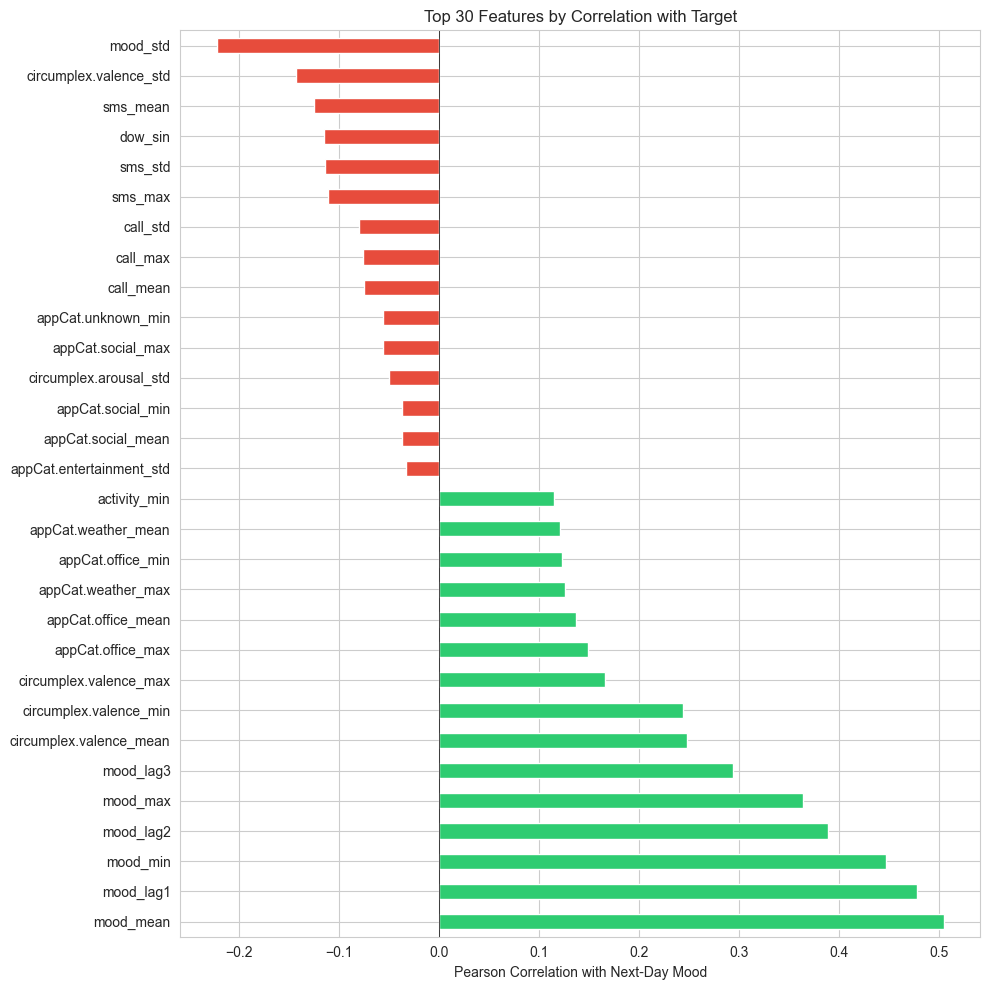

In [13]:
# Visualize top correlated features
top_n = 30
top_corr = pd.concat([correlations.head(top_n // 2), correlations.tail(top_n // 2)])

fig, ax = plt.subplots(figsize=(10, 10))
colors = ['#2ecc71' if v > 0 else '#e74c3c' for v in top_corr.values]
top_corr.plot(kind='barh', ax=ax, color=colors)
ax.set_xlabel('Pearson Correlation with Next-Day Mood')
ax.set_title(f'Top {top_n} Features by Correlation with Target')
ax.axvline(x=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

In [14]:
# Feature importance using a quick Random Forest
from sklearn.ensemble import RandomForestRegressor

X = features_df[feature_cols].copy()
y = features_df['target_mood'].copy()

# Drop any columns that are all NaN or constant
valid_cols = X.columns[X.std() > 0]
X = X[valid_cols]

rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X, y)

importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

print("Top 20 features by Random Forest importance:")
print(importances.head(20).to_string())
print(f"\nRF R-squared (training, for reference): {rf.score(X, y):.3f}")

Top 20 features by Random Forest importance:
mood_mean                   0.203311
mood_lag1                   0.108193
mood_lag3                   0.021758
mood_lag2                   0.020605
mood_std                    0.020506
circumplex.arousal_trend    0.016353
call_trend                  0.016164
dow_sin                     0.015334
activity_trend              0.015317
mood_trend                  0.013807
circumplex.valence_mean     0.013620
appCat.unknown_trend        0.012931
activity_std                0.012086
appCat.social_trend         0.012081
circumplex.valence_trend    0.011696
appCat.other_trend          0.011377
circumplex.arousal_mean     0.011010
sms_trend                   0.010758
appCat.builtin_trend        0.010640
appCat.utilities_trend      0.010562

RF R-squared (training, for reference): 0.902


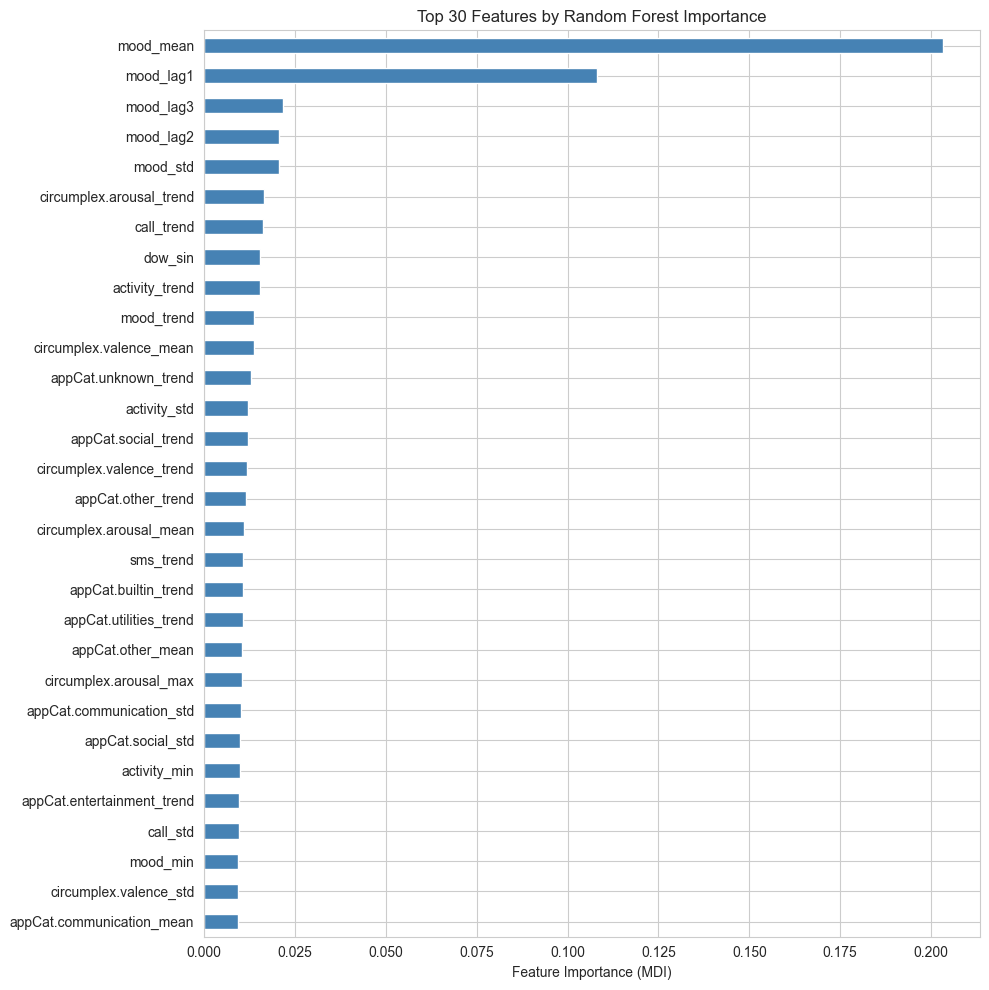

In [15]:
# Visualize Random Forest feature importances
fig, ax = plt.subplots(figsize=(10, 10))
importances.head(30).sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Feature Importance (MDI)')
ax.set_title('Top 30 Features by Random Forest Importance')
plt.tight_layout()
plt.show()

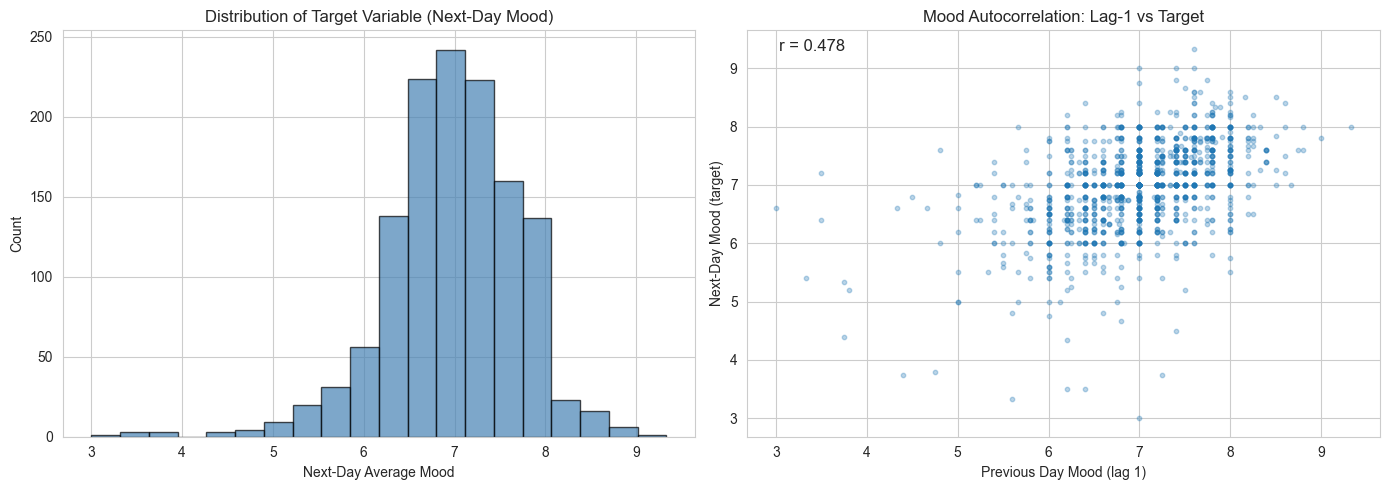

In [16]:
# Target distribution visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(features_df['target_mood'], bins=20, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].set_xlabel('Next-Day Average Mood')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of Target Variable (Next-Day Mood)')

# Scatter: mood_lag1 vs target
axes[1].scatter(features_df['mood_lag1'], features_df['target_mood'], alpha=0.3, s=10)
axes[1].set_xlabel('Previous Day Mood (lag 1)')
axes[1].set_ylabel('Next-Day Mood (target)')
axes[1].set_title('Mood Autocorrelation: Lag-1 vs Target')
r = features_df[['mood_lag1', 'target_mood']].corr().iloc[0, 1]
axes[1].annotate(f'r = {r:.3f}', xy=(0.05, 0.95), xycoords='axes fraction', fontsize=12)

plt.tight_layout()
plt.show()

### Results: Feature Analysis and Importance

**Correlation analysis** reveals that mood-related features dominate the relationship with next-day mood. The top correlations are:
- `mood_mean` (r = 0.504): the 7-day average mood is the single strongest linear predictor
- `mood_lag1` (r = 0.478): yesterday's mood is nearly as predictive, confirming strong day-to-day autocorrelation
- `mood_min` (r = 0.447) and `mood_lag2` (r = 0.389): recent mood history matters significantly
- `circumplex.valence_mean` (r = 0.248): emotional valence is the best non-mood predictor

The strongest negative correlations are relatively weak: `mood_std` (r = -0.222), `circumplex.valence_std` (r = -0.143), and `sms_mean` (r = -0.124). High mood variability within the window is associated with lower next-day mood, which is intuitive; unstable mood tends to precede worse outcomes.

**Random Forest importance** largely agrees with correlation analysis but offers additional insights. `mood_mean` (importance = 0.203) and `mood_lag1` (0.108) remain dominant. However, trend features (`circumplex.arousal_trend`, `call_trend`, `activity_trend`, `mood_trend`) appear in the top 10 by importance despite having weak linear correlations. This suggests nonlinear relationships that tree-based models can exploit. The day-of-week feature (`dow_sin`, importance = 0.015) also contributes, indicating weekly mood patterns.

The training R-squared of 0.902 from the Random Forest is encouraging but should be interpreted cautiously, as it reflects in-sample fit without cross-validation. The strong dominance of mood lag and mean features suggests that mood is highly autoregressive, which is consistent with psychological literature on mood inertia. For modeling, this means that historical mood features will likely carry most of the predictive signal, while behavioral features (app usage, calls, SMS) provide modest additional value.

## Summary

**What was done:**
- Transformed the long-format time series into daily aggregated summaries per patient
- Applied a sliding window approach (window = 7 days) to create instance-based features
- Engineered features per variable: mean, std, min, max, and trend (linear slope) over the window
- Added mood lag features (1, 2, 3 days back) and cyclical day-of-week encoding
- Target variable: next-day average mood

**Key observations:**
- The dataset is saved to `../data/dataset_features.csv` for use in Task 2 (modelling)
- Mood lag features (especially lag-1) are expected to be among the strongest predictors due to autocorrelation
- The sliding window captures both level (mean) and variability (std) of patient behaviour

**TODO:**
- Experiment with different window sizes (e.g., 3, 5, 14 days)
- Consider adding interaction features or ratio features
- Evaluate whether per-patient normalization improves model performance
- Test additional aggregation functions (e.g., median, skewness)
- Consider adding a patient-level identifier encoding for models that benefit from it